
GEM DATA PROCESSING WITH DUAL-WEIGHTED VULNERABILITY INDICES

STEP 1: Processing GEM exposure data...
----------------------------------------------------------------------


Decoding taxonomies: 100%|██████████| 3654/3654 [02:35<00:00, 23.53it/s]


   Calculating cost-weighted vulnerability shares...
   Calculating dwelling-weighted vulnerability shares...
✅ Processed 9,513 building records across 215 countries.
   Total records: 9,513
   Countries: 215
   Unique taxonomies: 3654

STEP 2: Calculating cost-weighted vulnerability indices...
----------------------------------------------------------------------
✅ Created 20 cost-weighted indicators.

STEP 3: Calculating dwelling-weighted vulnerability indices...
----------------------------------------------------------------------
✅ Created 11 dwelling-weighted indicators.

STEP 4: Combining cost-weighted and dwelling-weighted indicators...
----------------------------------------------------------------------
✅ Combined dataset contains 31 total indicators.
   Cost-weighted: 20
   Dwelling-weighted: 11

STEP 5: Saving combined results...
----------------------------------------------------------------------
✅ Results saved: country_vulnerability_class_shares.csv
   Total columns: 

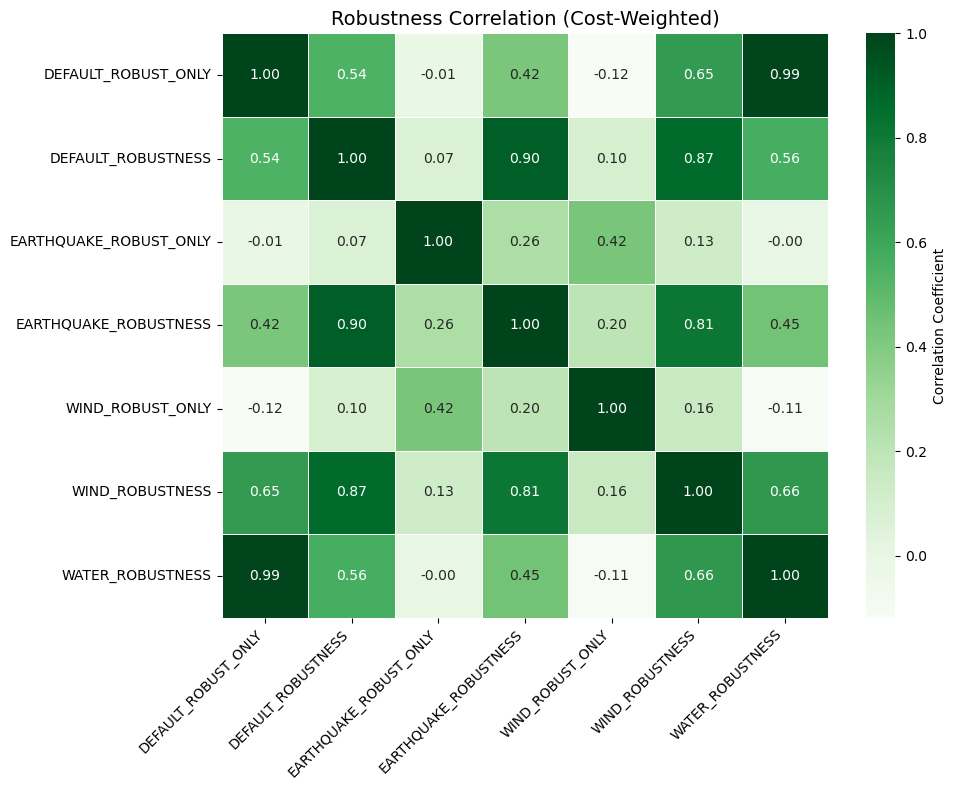

   Saved: vulnerability_correlation_cost.png


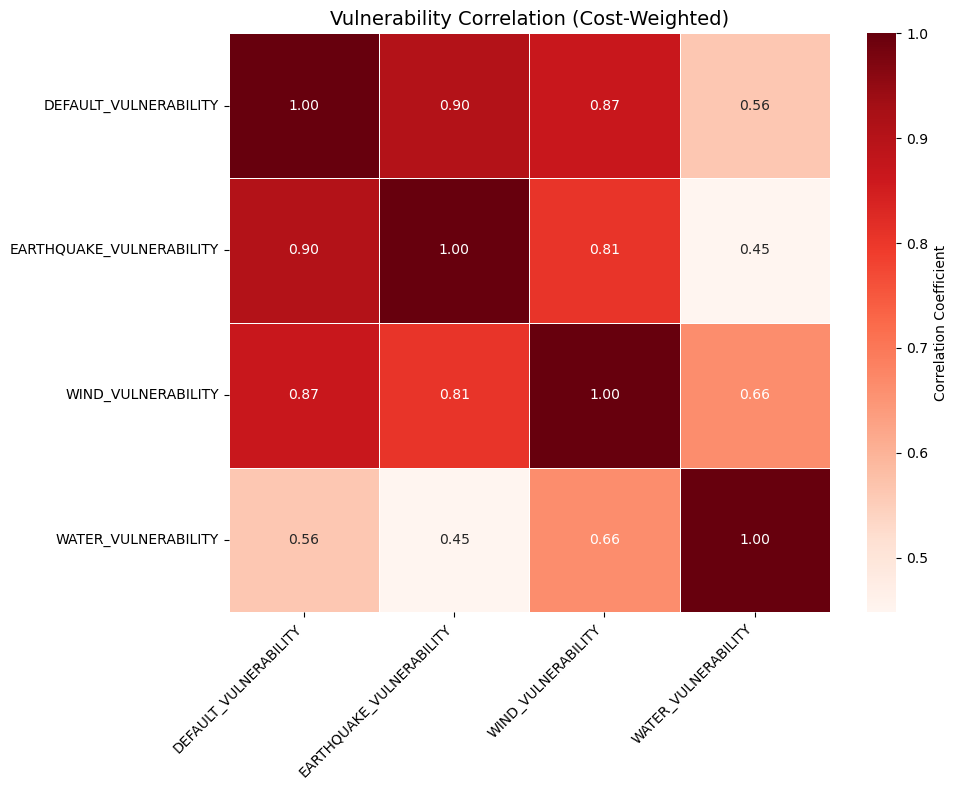

   Saved: robustness_correlation_dwelling.png


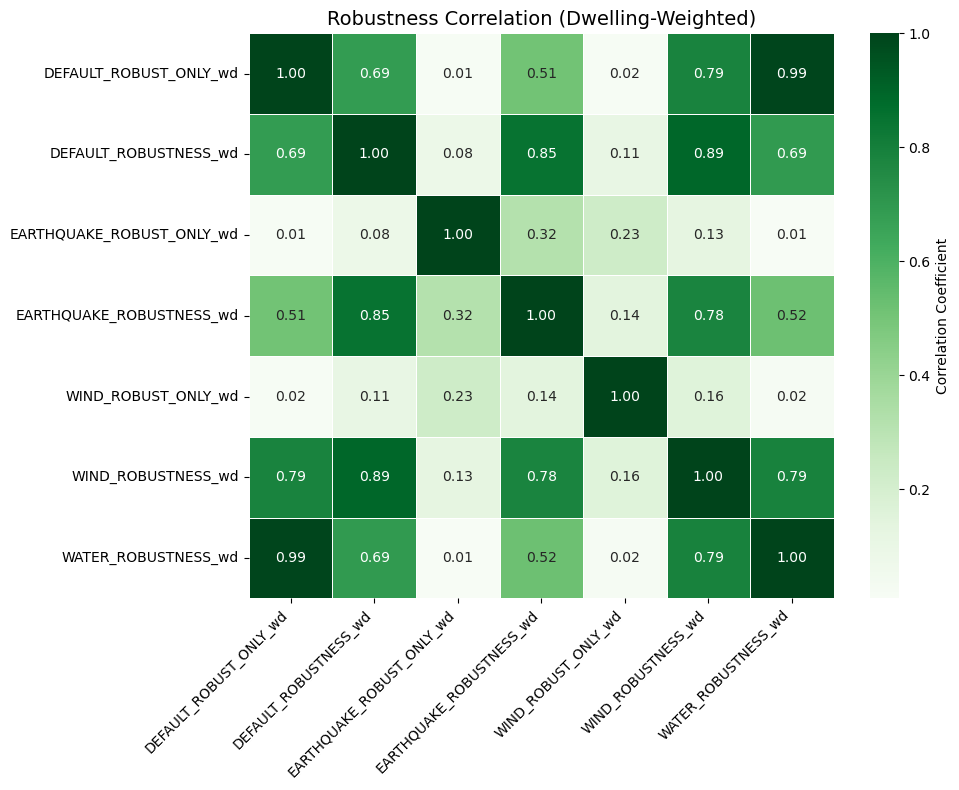

   Saved: vulnerability_correlation_dwelling.png


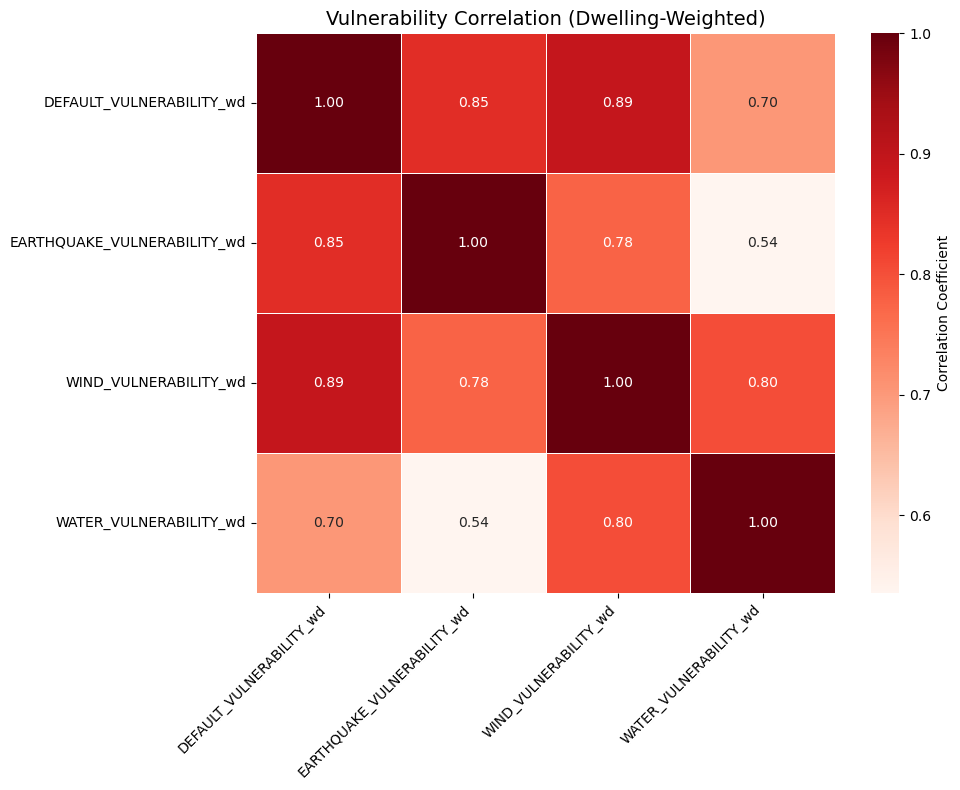


CORRELATION MATRICES SUMMARY

Cost-Weighted Robustness:
                        DEFAULT_ROBUST_ONLY  DEFAULT_ROBUSTNESS  \
DEFAULT_ROBUST_ONLY                    1.00                0.54   
DEFAULT_ROBUSTNESS                     0.54                1.00   
EARTHQUAKE_ROBUST_ONLY                -0.01                0.07   
EARTHQUAKE_ROBUSTNESS                  0.42                0.90   
WIND_ROBUST_ONLY                      -0.12                0.10   
WIND_ROBUSTNESS                        0.65                0.87   
WATER_ROBUSTNESS                       0.99                0.56   

                        EARTHQUAKE_ROBUST_ONLY  EARTHQUAKE_ROBUSTNESS  \
DEFAULT_ROBUST_ONLY                      -0.01                   0.42   
DEFAULT_ROBUSTNESS                        0.07                   0.90   
EARTHQUAKE_ROBUST_ONLY                    1.00                   0.26   
EARTHQUAKE_ROBUSTNESS                     0.26                   1.00   
WIND_ROBUST_ONLY                         

In [8]:
"""
Combined GEM Data Processing and Vulnerability Index Calculation
=================================================================
This script processes Global Exposure Model (GEM) building exposure data,
assigns vulnerability classes, and calculates integrated vulnerability indices.
Creates two sets of indicators: cost-weighted and dwelling-weighted.
The code is build based on the original code by Robin Middelanis <rmiddelanis@worldbank.org>. 

https://github.com/rmiddelanis/global-unbreakable-model/blob/main/src/unbreakable/scenario/data_processing/gather_gem_data.py

"""

import json
import os
import re
import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION
# ============================================================================

# Countries using HAZUS taxonomy instead of GEM
HAZUS_COUNTRIES = ['VIR', 'PRI', 'CAN', 'USA']

# Water hazards to integrate (based on 1.00 correlation)
HAZARDS_TO_INTEGRATE = ['FLOOD', 'STORM_SURGE', 'TSUNAMI']
INTEGRATED_WATER_HAZARD = 'WATER'


# ============================================================================
# PART 1: GEM DATA PROCESSING FUNCTIONS
# ============================================================================

def load_mapping(gem_fields_path_, vuln_class_mapping_):
    """
    Loads the GEM (Global Exposure Model) taxonomy fields and vulnerability class mapping.

    Args:
        gem_fields_path_ (str): Path to the GEM taxonomy fields JSON file.
        vuln_class_mapping_ (str): Path to the vulnerability class mapping Excel file.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: DataFrame with the vulnerability class mapping.
            - dict: Dictionary mapping field values to their types.
    """
    gem_fields = json.load(open(gem_fields_path_, 'r'))
    field_value_to_type_map = {
        v: k.lower() 
        for k in gem_fields.keys() 
        for l in gem_fields[k].keys() 
        for v in gem_fields[k][l]
    }

    mapping_df = pd.read_excel(vuln_class_mapping_, header=0)
    mapping_df.drop('comment', inplace=True, axis=1)
    mapping_df.rename(columns={'combined': 'default'}, inplace=True)
    mapping_df.set_index(['lat_load_mat', 'lat_load_sys', 'height'], inplace=True)
    
    # Expand combined categories (e.g., "A+B" becomes separate "A" and "B" columns)
    for c in mapping_df.columns:
        if '+' in c:
            for c_ in c.split('+'):
                if len(c_) > 1:
                    mapping_df[c_] = mapping_df[c]
            mapping_df = mapping_df.drop(c, axis=1)
    
    mapping_df = mapping_df.sort_index()
    return mapping_df, field_value_to_type_map


def assign_vulnerability(material, resistance_system, height, mapping, verbose=True):
    """
    Assigns a vulnerability class based on material, resistance system, and height.
    Uses hierarchical matching: material -> system -> height -> default.

    Args:
        material (str): Material type (e.g., 'CR' for concrete).
        resistance_system (str): Lateral load resistance system.
        height (str): Building height specification.
        mapping (pd.DataFrame): DataFrame containing the vulnerability class mapping.
        verbose (bool): Whether to print warnings. Defaults to True.

    Returns:
        pd.Series: A Series containing the assigned vulnerability class.

    Raises:
        ValueError: If the material is unknown or cannot be mapped.
    """
    if material in mapping.index:
        if len(mapping.loc[material]) == 1:
            return mapping.loc[[material]].transpose().squeeze().rename('vulnerability')
        else:
            if type(resistance_system) is str and len(resistance_system) > 0:
                resistance_system = resistance_system.split('+')[0]
            
            if (material, resistance_system) in mapping.index:
                if len(mapping.loc[(material, resistance_system)]) == 1:
                    return mapping.loc[material, resistance_system].transpose().squeeze().rename('vulnerability')
                else:
                    if type(height) is str and len(height) > 0:
                        height = height.split(':')[1].split('+')[0].split('-' if '-' in height else ',')
                        if len(height) > 1 and len(height[1]) == 0 or len(height) == 1:
                            height = [height[0], height[0]]
                        try:
                            height = [int(h) for h in height]
                            for h_idx in mapping.loc[(material, resistance_system)].index:
                                if h_idx != 'default':
                                    h_range = sorted([int(h) for h in h_idx.split(':')[1].split(',')])
                                    if h_range[0] <= height[0] <= h_range[1] or h_range[0] <= height[1] <= h_range[1]:
                                        return mapping.loc[(material, resistance_system, h_idx)].transpose().squeeze().rename('vulnerability')
                        except ValueError as e:
                            if verbose:
                                print(f"Warning: could not parse height value {height} to integer. Using default value.")
                
                return mapping.loc[(material, resistance_system, 'default')].transpose().squeeze().rename('vulnerability')
            
            return mapping.loc[(material, 'default')].transpose().squeeze().rename('vulnerability')
    else:
        raise ValueError(f"Could not assign vulnerability for unknown material {material}.")


def decode_taxonomy(taxonomy, field_value_to_type_map, keep_unknown=False, verbose=True):
    """
    Decodes a GEM taxonomy string into its components.
    Example: "CR/LFINF/H:3" -> {material: 'CR', system: 'LFINF', height: 'H:3'}

    Args:
        taxonomy (str): GEM taxonomy string.
        field_value_to_type_map (dict): Mapping of field values to their types.
        keep_unknown (bool): Whether to keep unknown attributes. Defaults to False.
        verbose (bool): Whether to print warnings. Defaults to True.

    Returns:
        pd.DataFrame: DataFrame with decoded taxonomy components.
    """
    res = pd.DataFrame(
        {col: [[]] for col in ['lat_load_mat', 'lat_load_sys', 'height', 'unknown']},
        index=[taxonomy]
    )
    res.index.name = 'taxonomy'
    
    attribute_types = {
        attribute: identify_gem_attribute_type(attribute, field_value_to_type_map, verbose)
        for attribute in taxonomy.split('/')
    }
    
    for attribute, attribute_type in attribute_types.items():
        res.loc[[taxonomy], attribute_type] = (
            res.loc[taxonomy, attribute_type] +
            pd.DataFrame(index=[taxonomy], columns=attribute_type, data=[[[attribute]] * len(attribute_type)])
        )
    
    for col in res.columns:
        if len(res.loc[taxonomy, col]) == 0:
            res.loc[taxonomy, col] = np.nan
        elif len(res.loc[taxonomy, col]) == 1:
            res.loc[taxonomy, col] = res.loc[taxonomy, col][0]
        elif len(res.loc[taxonomy, col]) > 1:
            if res.loc[taxonomy, col][0] in ['MATO', 'UNK'] and 'UNK' in res.loc[taxonomy, col][0]:
                res.loc[taxonomy, col] = res.loc[taxonomy, col][0]
            elif verbose:
                print(f"Warning: Multiple attributes have been mapped to the same type for taxonomy {taxonomy}.")
    
    if keep_unknown:
        return res
    else:
        return res.drop('unknown', axis=1)


def identify_gem_attribute_type(attribute, field_value_to_type_map, verbose=True):
    """
    Identifies the type of a GEM attribute (material, system, height, etc.).

    Args:
        attribute (str): GEM attribute string.
        field_value_to_type_map (dict): Mapping of field values to their types.
        verbose (bool): Whether to print warnings. Defaults to True.

    Returns:
        np.ndarray: Array of identified attribute types.
    """
    if len(attribute) == 0 and verbose:
        print("Warning: Empty attribute.")
    
    types = np.unique([
        field_value_to_type_map.get(field.split(':')[0], 'unknown') 
        for field in attribute.split('+')
    ])
    
    if len(types) == 1 and 'unknown' in types and verbose:
        print(f"Warning: Unknown type for attribute {attribute}.")
    elif len(types) == 2 and 'unknown' in types:
        types = types[types != 'unknown']
    elif len(types) > 1 and verbose:
        print(f"Warning: Multiple types {types} for attribute {attribute}.")
    
    return types


def gather_gem_data(gem_repo_root_dir_, hazus_gem_mapping_path_, gem_fields_path_, 
                    vuln_class_mapping_, verbose=True):
    """
    Gathers and processes GEM (Global Exposure Model) data.
    **Note: This function processes ONLY residential ('Res') occupancy data.**
    **Creates vulnerability shares for both cost-weighted and dwelling-weighted.**

    Args:
        gem_repo_root_dir_ (str): Root directory of the GEM repository.
        hazus_gem_mapping_path_ (str): Path to the HAZUS-GEM mapping CSV file.
        gem_fields_path_ (str): Path to the GEM taxonomy fields JSON file.
        vuln_class_mapping_ (str): Path to the vulnerability class mapping Excel file.
        verbose (bool): Whether to print processing information. Defaults to True.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: GEM data with decoded taxonomy and assigned vulnerabilities.
            - pd.DataFrame: Cost-weighted vulnerability class shares by country and hazard.
            - pd.DataFrame: Dwelling-weighted vulnerability class shares by country and hazard.
    """
    # Initialize an empty DataFrame
    gem = pd.DataFrame()

    vars_to_keep = {
        'ID_0': 'iso3', 
        'NAME_0': 'country', 
        'OCCUPANCY': 'building_type', 
        'MACRO_TAXO': 'macro_taxonomy',
        'TAXONOMY': 'taxonomy', 
        'BUILDINGS': 'n_buildings', 
        'DWELLINGS': 'n_dwellings',
        'TOTAL_AREA_SQM': 'total_area_sqm', 
        'TOTAL_REPL_COST_USD': 'total_replacement_cost',
        'COST_CONTENTS_USD': 'contents_cost', 
        'COST_STRUCTURAL_USD': 'structural_cost',
        'COST_NONSTRUCTURAL_USD': 'nonstructural_cost',
    }
    
    index_vars = ['ID_0', 'NAME_0', 'OCCUPANCY', 'MACRO_TAXO', 'TAXONOMY']

    # Walk through root directory to find exposure data
    for dirpath, dirnames, filenames in os.walk(gem_repo_root_dir_):
        for filename in filenames:
            if filename == 'Exposure_Summary_Taxonomy.csv':
                file_path = str(os.path.join(dirpath, filename))
                df = pd.read_csv(file_path)

                # *** FILTER: Keep ONLY residential ('Res') data ***
                if 'OCCUPANCY' in df.columns:
                    df = df[df['OCCUPANCY'].astype(str) == 'Res'].copy()

                if df.empty:
                    continue

                # Check for missing variables (silently handle)
                vars_diff = np.setdiff1d(list(vars_to_keep.keys()), df.columns)
                
                df = df[list(set(vars_to_keep.keys()) - set(vars_diff))].groupby(index_vars).sum().reset_index()
                gem = pd.concat([gem, df])
    
    # Check if data was collected
    if gem.empty:
        if verbose:
            print("\nWarning: No 'Res' data found. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    gem.rename(vars_to_keep, axis=1, inplace=True)
    gem.reset_index(inplace=True, drop=True)

    # Clean up taxonomy strings (replace problematic '+' in mixed materials)
    replace_strings = {
        s: s.replace('+', '-') for s in
        ['MIX(MUR+W)', 'MIX(MR+W)', 'MIX(S+CR)', 'MIX(MUR+CR)', 'MIX(W+EU)', 
         'MIX(MUR+STRUB+W)', 'MIX(MUR+STDRE+W)', 'MIX(S+CR+PC)']
    }
    for s, r in replace_strings.items():
        gem.taxonomy = gem.taxonomy.apply(lambda x: x.replace(s, r))

    # Handle countries with HAZUS taxonomy
    hazus_gem_mapping = pd.read_csv(hazus_gem_mapping_path_, index_col=0).astype(str)
    hazus_gem_mapping.loc['MH', 'gem_str'] = 'INF/'  # Mobile homes -> informal
    hazus_gem_mapping.loc['W3', 'gem_str'] = 'W/'    # W3 -> general wood
    hazus_gem_mapping.loc['W4', 'gem_str'] = 'W/'    # W4 -> general wood
    
    if not gem.loc[gem.iso3.isin(HAZUS_COUNTRIES)].empty:
        gem.loc[gem.iso3.isin(HAZUS_COUNTRIES), 'taxonomy'] = (
            gem.loc[gem.iso3.isin(HAZUS_COUNTRIES), 'taxonomy'].apply(
                lambda x: hazus_gem_mapping.loc[x.split('-')[1].split('/')[0], 'gem_str']
            )
        )

    # Load vulnerability mapping
    vulnerability_mapping, field_value_to_type_map = load_mapping(
        gem_fields_path_=gem_fields_path_,
        vuln_class_mapping_=vuln_class_mapping_
    )

    # Decode all unique taxonomy strings
    unique_tax_strings = gem.taxonomy.unique()
    decoded_tax_strings = pd.concat([
        decode_taxonomy(t, field_value_to_type_map, keep_unknown=False, verbose=False)
        for t in tqdm.tqdm(unique_tax_strings, desc="Decoding taxonomies", disable=not verbose)
    ])
    
    res = pd.merge(gem, decoded_tax_strings, how='left', on='taxonomy')

    # Handle special cases for material assignment
    res.loc[
        (res.lat_load_mat.isna()) &
        (res.lat_load_sys.apply(lambda x: 'LN' in x if type(x) is str else False)), 
        "lat_load_mat"
    ] = 'UNK'
    
    res.loc[
        (res.lat_load_mat.isna()) &
        (res.taxonomy.apply(lambda x: x.startswith('UNK'))), 
        "lat_load_mat"
    ] = 'UNK'

    # Assign vulnerability classes
    vulnerability = res.apply(
        lambda x: assign_vulnerability(
            x.lat_load_mat, x.lat_load_sys, x.height, 
            vulnerability_mapping, verbose=False
        ), 
        axis=1
    )
    
    merged = pd.concat([res, vulnerability], axis=1)

    # Calculate vulnerability class shares - COST WEIGHTED
    if verbose:
        print("   Calculating cost-weighted vulnerability shares...")
    
    v_class_shares_cost = []
    for hazard_class in vulnerability.columns:
        v_class_shares_ = merged.groupby(['iso3', 'country', f'{hazard_class}'])['total_replacement_cost'].sum()
        v_class_shares_ = v_class_shares_ / merged.groupby('iso3')['total_replacement_cost'].sum()
        v_class_shares_ = v_class_shares_.unstack()
        v_class_shares_.fillna(0, inplace=True)
        v_class_shares_.columns = pd.MultiIndex.from_product([[hazard_class], v_class_shares_.columns])
        v_class_shares_cost.append(v_class_shares_)
    
    v_class_shares_cost = pd.concat(v_class_shares_cost, axis=1)
    
    # Calculate vulnerability class shares - DWELLING WEIGHTED
    if verbose:
        print("   Calculating dwelling-weighted vulnerability shares...")
    
    v_class_shares_dwelling = []
    for hazard_class in vulnerability.columns:
        v_class_shares_ = merged.groupby(['iso3', 'country', f'{hazard_class}'])['n_dwellings'].sum()
        v_class_shares_ = v_class_shares_ / merged.groupby('iso3')['n_dwellings'].sum()
        v_class_shares_ = v_class_shares_.unstack()
        v_class_shares_.fillna(0, inplace=True)
        v_class_shares_.columns = pd.MultiIndex.from_product([[hazard_class], v_class_shares_.columns])
        v_class_shares_dwelling.append(v_class_shares_)
    
    v_class_shares_dwelling = pd.concat(v_class_shares_dwelling, axis=1)
    
    if verbose:
        print(f"✅ Processed {len(merged):,} building records across {gem.iso3.nunique()} countries.")
    
    return merged, v_class_shares_cost, v_class_shares_dwelling


# ============================================================================
# PART 2: VULNERABILITY INDEX CALCULATION AND WATER HAZARD INTEGRATION
# ============================================================================

def calculate_vulnerability_indices(v_class_shares_raw, suffix='', verbose=True):
    """
    Calculates aggregated vulnerability indices (Robustness, Vulnerability, Robust_Only)
    and integrates water-related hazards into a single WATER index.
    
    **Note: Handles cases where ROBUST category may not exist (e.g., for FLOOD).**

    Args:
        v_class_shares_raw (pd.DataFrame): Raw vulnerability class shares from gather_gem_data().
        suffix (str): Suffix to add to column names (e.g., '_wd' for dwelling-weighted).
        verbose (bool): Whether to print processing information.

    Returns:
        pd.DataFrame: Processed vulnerability shares with integrated indices.
    """
    if v_class_shares_raw.empty:
        if verbose:
            print("Warning: Empty input DataFrame. Returning empty result.")
        return pd.DataFrame()
    
    # Flatten multi-index columns for easier processing
    df_flat = v_class_shares_raw.copy()
    df_flat.columns = ['_'.join(col).strip() for col in df_flat.columns.values]
    
    # Prepare for processing
    df_vuln_processed = df_flat.copy()
    new_vuln_cols = []
    processed_types = set()
    
    # Pattern to remove unwanted suffixes
    UNWANTED_SUFFIX_PATTERN = r'_UNNAMED:\_\d+$|_UNNAMED'
    
    # Clean up column names
    cleaned_columns = {}
    for col in df_vuln_processed.columns:
        col_clean = re.sub(UNWANTED_SUFFIX_PATTERN, '', col.upper())
        col_clean = col_clean.replace(' ', '_').replace('__', '_')
        cleaned_columns[col] = col_clean
    
    df_vuln_processed.rename(columns=cleaned_columns, inplace=True)
    
    # Create aggregated indices for ALL hazards
    for col in df_vuln_processed.columns:
        match = re.match(r'^([A-Z_]+)_(FRAGILE|MEDIAN|ROBUST)$', col)
        if not match:
            continue
        
        risk_type = match.group(1)
        
        if risk_type not in processed_types:
            fragile_col = f'{risk_type}_FRAGILE'
            median_col = f'{risk_type}_MEDIAN'
            robust_col = f'{risk_type}_ROBUST'
            
            # 1. ROBUST_ONLY (Pure Robustness): Share of ROBUST buildings (if exists)
            robust_only_col_name = f'{risk_type}_ROBUST_ONLY{suffix}'
            if robust_col in df_vuln_processed.columns:
                df_vuln_processed[robust_only_col_name] = df_vuln_processed[robust_col]
                new_vuln_cols.append(robust_only_col_name)
            
            # 2. ROBUSTNESS Index: MEDIAN + ROBUST (or just MEDIAN if ROBUST doesn't exist)
            robustness_col_name = f'{risk_type}_ROBUSTNESS{suffix}'
            if robust_col in df_vuln_processed.columns and median_col in df_vuln_processed.columns:
                df_vuln_processed[robustness_col_name] = (
                    df_vuln_processed[median_col] + df_vuln_processed[robust_col]
                )
            elif median_col in df_vuln_processed.columns:
                # If ROBUST doesn't exist (like FLOOD), use only MEDIAN
                df_vuln_processed[robustness_col_name] = df_vuln_processed[median_col]
            else:
                processed_types.add(risk_type)
                continue
            
            new_vuln_cols.append(robustness_col_name)
            
            # 3. VULNERABILITY Index: FRAGILE only
            vulnerability_col_name = f'{risk_type}_VULNERABILITY{suffix}'
            if fragile_col in df_vuln_processed.columns:
                df_vuln_processed[vulnerability_col_name] = df_vuln_processed[fragile_col]
                new_vuln_cols.append(vulnerability_col_name)
            
            processed_types.add(risk_type)
    
    # Integrate water hazards into single WATER index
    integrated_robustness_col = f'{INTEGRATED_WATER_HAZARD}_ROBUSTNESS{suffix}'
    integrated_vulnerability_col = f'{INTEGRATED_WATER_HAZARD}_VULNERABILITY{suffix}'
    integrated_robust_only_col = f'{INTEGRATED_WATER_HAZARD}_ROBUST_ONLY{suffix}'
    
    # Use FLOOD as the representative (guaranteed to exist after processing)
    if f'FLOOD_ROBUSTNESS{suffix}' in df_vuln_processed.columns:
        df_vuln_processed[integrated_robustness_col] = df_vuln_processed[f'FLOOD_ROBUSTNESS{suffix}']
    
    if f'FLOOD_VULNERABILITY{suffix}' in df_vuln_processed.columns:
        df_vuln_processed[integrated_vulnerability_col] = df_vuln_processed[f'FLOOD_VULNERABILITY{suffix}']
    
    # Only create ROBUST_ONLY if it exists for FLOOD
    if f'FLOOD_ROBUST_ONLY{suffix}' in df_vuln_processed.columns:
        df_vuln_processed[integrated_robust_only_col] = df_vuln_processed[f'FLOOD_ROBUST_ONLY{suffix}']
    
    # Drop redundant water hazard columns and original raw columns
    cols_to_drop = []
    for hazard in HAZARDS_TO_INTEGRATE:
        for suf in ['_ROBUSTNESS', '_VULNERABILITY', '_ROBUST_ONLY', '_FRAGILE', '_MEDIAN', '_ROBUST']:
            col_name = f'{hazard}{suf}{suffix}'
            if col_name in df_vuln_processed.columns:
                cols_to_drop.append(col_name)
    
    # Also drop the original raw columns (without suffix) for all hazards
    for col in list(df_vuln_processed.columns):
        if any(col.endswith(raw_suffix) for raw_suffix in ['_FRAGILE', '_MEDIAN', '_ROBUST']):
            if not col.endswith(suffix):  # Don't drop if it already has the target suffix
                cols_to_drop.append(col)
    
    cols_to_drop = list(set(cols_to_drop))
    df_vuln_processed.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    
    return df_vuln_processed


def visualize_correlations(df_cost, df_dwelling, output_dir=None, verbose=True):
    """
    Creates correlation heatmaps for both cost-weighted and dwelling-weighted indices.

    Args:
        df_cost (pd.DataFrame): Cost-weighted vulnerability data.
        df_dwelling (pd.DataFrame): Dwelling-weighted vulnerability data.
        output_dir (str, optional): Directory to save plots. If None, plots are displayed only.
        verbose (bool): Whether to print information.

    Returns:
        dict: Dictionary containing all correlation matrices.
    """
    results = {}
    
    if df_cost.empty and df_dwelling.empty:
        if verbose:
            print("Warning: Empty DataFrames. Cannot create visualizations.")
        return results
    
    # ========================================================================
    # COST-WEIGHTED CORRELATIONS
    # ========================================================================
    if not df_cost.empty:
        robustness_cols_cost = [col for col in df_cost.columns if 'ROBUSTNESS' in col or 'ROBUST_ONLY' in col]
        vulnerability_cols_cost = [col for col in df_cost.columns if 'VULNERABILITY' in col]
        
        # Robustness - Cost Weighted
        if robustness_cols_cost:
            df_robustness_cost = df_cost[robustness_cols_cost].copy()
            corr_r_cost = df_robustness_cost.corr()
            results['robustness_cost'] = corr_r_cost
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                corr_r_cost,
                annot=True,
                cmap='Greens',
                fmt=".2f",
                linewidths=.5,
                cbar_kws={'label': 'Correlation Coefficient'}
            )
            plt.title('Robustness Correlation (Cost-Weighted)', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            if output_dir:
                plt.savefig(os.path.join(output_dir, 'robustness_correlation_cost.png'), dpi=300)
                if verbose:
                    print(f"   Saved: robustness_correlation_cost.png")
            plt.show()
        
        # Vulnerability - Cost Weighted
        if vulnerability_cols_cost:
            df_vulnerability_cost = df_cost[vulnerability_cols_cost].copy()
            corr_v_cost = df_vulnerability_cost.corr()
            results['vulnerability_cost'] = corr_v_cost
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                corr_v_cost,
                annot=True,
                cmap='Reds',
                fmt=".2f",
                linewidths=.5,
                cbar_kws={'label': 'Correlation Coefficient'}
            )
            plt.title('Vulnerability Correlation (Cost-Weighted)', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            if output_dir:
                plt.savefig(os.path.join(output_dir, 'vulnerability_correlation_cost.png'), dpi=300)
                if verbose:
                    print(f"   Saved: vulnerability_correlation_cost.png")
            plt.show()
    
    # ========================================================================
    # DWELLING-WEIGHTED CORRELATIONS
    # ========================================================================
    if not df_dwelling.empty:
        robustness_cols_dwelling = [col for col in df_dwelling.columns if 'ROBUSTNESS' in col or 'ROBUST_ONLY' in col]
        vulnerability_cols_dwelling = [col for col in df_dwelling.columns if 'VULNERABILITY' in col]
        
        # Robustness - Dwelling Weighted
        if robustness_cols_dwelling:
            df_robustness_dwelling = df_dwelling[robustness_cols_dwelling].copy()
            corr_r_dwelling = df_robustness_dwelling.corr()
            results['robustness_dwelling'] = corr_r_dwelling
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                corr_r_dwelling,
                annot=True,
                cmap='Greens',
                fmt=".2f",
                linewidths=.5,
                cbar_kws={'label': 'Correlation Coefficient'}
            )
            plt.title('Robustness Correlation (Dwelling-Weighted)', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            if output_dir:
                plt.savefig(os.path.join(output_dir, 'robustness_correlation_dwelling.png'), dpi=300)
                if verbose:
                    print(f"   Saved: robustness_correlation_dwelling.png")
            plt.show()
        
        # Vulnerability - Dwelling Weighted
        if vulnerability_cols_dwelling:
            df_vulnerability_dwelling = df_dwelling[vulnerability_cols_dwelling].copy()
            corr_v_dwelling = df_vulnerability_dwelling.corr()
            results['vulnerability_dwelling'] = corr_v_dwelling
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                corr_v_dwelling,
                annot=True,
                cmap='Reds',
                fmt=".2f",
                linewidths=.5,
                cbar_kws={'label': 'Correlation Coefficient'}
            )
            plt.title('Vulnerability Correlation (Dwelling-Weighted)', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            if output_dir:
                plt.savefig(os.path.join(output_dir, 'vulnerability_correlation_dwelling.png'), dpi=300)
                if verbose:
                    print(f"   Saved: vulnerability_correlation_dwelling.png")
            plt.show()
    
    # Print correlation summaries
    if verbose:
        print("\n" + "="*70)
        print("CORRELATION MATRICES SUMMARY")
        print("="*70)
        
        if 'robustness_cost' in results:
            print("\nCost-Weighted Robustness:")
            print(results['robustness_cost'].round(2))
        
        if 'vulnerability_cost' in results:
            print("\nCost-Weighted Vulnerability:")
            print(results['vulnerability_cost'].round(2))
        
        if 'robustness_dwelling' in results:
            print("\nDwelling-Weighted Robustness:")
            print(results['robustness_dwelling'].round(2))
        
        if 'vulnerability_dwelling' in results:
            print("\nDwelling-Weighted Vulnerability:")
            print(results['vulnerability_dwelling'].round(2))
        
        print("="*70 + "\n")
    
    return results


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    
    print("\n" + "="*70)
    print("GEM DATA PROCESSING WITH DUAL-WEIGHTED VULNERABILITY INDICES")
    print("="*70 + "\n")
    
    # ------------------------------------------------------------------------
    # USER CONFIGURATION - Modify these paths according to your setup
    # ------------------------------------------------------------------------
    
    BASE_DATA_DIR = r"C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_raw\GEM_vulnerability"
    OUTPUT_DIR = r"C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed"
    
    # Create output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Input file paths
    gem_repo_root_dir = os.path.join(BASE_DATA_DIR, 'global_exposure_model')
    vulnerability_class_mapping = os.path.join(BASE_DATA_DIR, "gem-to-vulnerability_mapping_per_hazard.xlsx")
    hazus_gem_mapping_path = os.path.join(BASE_DATA_DIR, 'hazus-gem_mapping.csv')
    gem_fields_path = os.path.join(BASE_DATA_DIR, "gem_taxonomy_fields.json")
    
    # Output file path
    OUTPUT_FILE_NAME = "country_vulnerability_class_shares.csv"
    output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILE_NAME)
    
    # ------------------------------------------------------------------------
    # STEP 1: Process GEM Data and Assign Vulnerabilities
    # ------------------------------------------------------------------------
    
    print("STEP 1: Processing GEM exposure data...")
    print("-" * 70)
    
    gem_data, vuln_shares_cost, vuln_shares_dwelling = gather_gem_data(
        gem_repo_root_dir_=gem_repo_root_dir,
        hazus_gem_mapping_path_=hazus_gem_mapping_path,
        gem_fields_path_=gem_fields_path,
        vuln_class_mapping_=vulnerability_class_mapping,
        verbose=True
    )
    
    if gem_data.empty:
        print("\n❌ No data was processed. Please check your input files and paths.")
        exit(1)
    
    print(f"   Total records: {len(gem_data):,}")
    print(f"   Countries: {gem_data['iso3'].nunique()}")
    print(f"   Unique taxonomies: {gem_data['taxonomy'].nunique()}")
    
    # ------------------------------------------------------------------------
    # STEP 2: Calculate Vulnerability Indices (Cost-Weighted)
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("STEP 2: Calculating cost-weighted vulnerability indices...")
    print("-" * 70)
    
    vuln_indices_cost = calculate_vulnerability_indices(
        v_class_shares_raw=vuln_shares_cost,
        suffix='',  # No suffix for cost-weighted (default)
        verbose=False
    )
    
    if vuln_indices_cost.empty:
        print("\n❌ Cost-weighted vulnerability index calculation failed.")
        exit(1)
    
    print(f"✅ Created {len(vuln_indices_cost.columns)} cost-weighted indicators.")
    
    # ------------------------------------------------------------------------
    # STEP 3: Calculate Vulnerability Indices (Dwelling-Weighted)
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("STEP 3: Calculating dwelling-weighted vulnerability indices...")
    print("-" * 70)
    
    vuln_indices_dwelling = calculate_vulnerability_indices(
        v_class_shares_raw=vuln_shares_dwelling,
        suffix='_wd',  # Add '_wd' suffix for dwelling-weighted
        verbose=False
    )
    
    if vuln_indices_dwelling.empty:
        print("\n❌ Dwelling-weighted vulnerability index calculation failed.")
        exit(1)
    
    print(f"✅ Created {len(vuln_indices_dwelling.columns)} dwelling-weighted indicators.")
    
    # ------------------------------------------------------------------------
    # STEP 4: Combine Both Sets of Indicators
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("STEP 4: Combining cost-weighted and dwelling-weighted indicators...")
    print("-" * 70)
    
    # Merge the two dataframes
    vuln_combined = pd.merge(
        vuln_indices_cost,
        vuln_indices_dwelling,
        left_index=True,
        right_index=True,
        how='outer'
    )
    
    print(f"✅ Combined dataset contains {len(vuln_combined.columns)} total indicators.")
    print(f"   Cost-weighted: {len(vuln_indices_cost.columns)}")
    print(f"   Dwelling-weighted: {len(vuln_indices_dwelling.columns)}")
    
    # ------------------------------------------------------------------------
    # STEP 5: Save Combined Results
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("STEP 5: Saving combined results...")
    print("-" * 70)
    
    vuln_combined.to_csv(output_path)
    print(f"✅ Results saved: {OUTPUT_FILE_NAME}")
    print(f"   Total columns: {len(vuln_combined.columns)}")
    print(f"   Total countries: {len(vuln_combined)}")
    
    # ------------------------------------------------------------------------
    # STEP 6: Generate Visualizations
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("STEP 6: Generating correlation visualizations...")
    print("-" * 70)
    
    correlations = visualize_correlations(
        df_cost=vuln_indices_cost,
        df_dwelling=vuln_indices_dwelling,
        output_dir=OUTPUT_DIR,
        verbose=True
    )
    
    # ------------------------------------------------------------------------
    # FINAL SUMMARY
    # ------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("PROCESSING COMPLETE!")
    print("="*70)
    print(f"\n✅ Processed {len(gem_data):,} residential building records")
    print(f"✅ Covering {gem_data['iso3'].nunique()} countries")
    print(f"✅ Created two sets of vulnerability indicators:")
    print(f"   • Cost-weighted (default names): {len(vuln_indices_cost.columns)} indicators")
    print(f"   • Dwelling-weighted ('_wd' suffix): {len(vuln_indices_dwelling.columns)} indicators")
    print(f"✅ Integrated {len(HAZARDS_TO_INTEGRATE)} water hazards into '{INTEGRATED_WATER_HAZARD}' index")
    print(f"✅ Generated 4 correlation heatmaps (2 for each weighting method)")
    print(f"\n📁 Output file: {output_path}")
    print(f"📁 Visualizations: {OUTPUT_DIR}")
    print("="*70 + "\n")


# new 